# Flowsheet Optimization with pounce and asdex

This notebook connects three libraries:

- **difflow** builds the process model,
- **asdex** detects the sparsity structure of the model's derivatives, symbolically,
- **pounce** solves the resulting nonlinear program.

JAX is the glue. Every difflow model is a traced JAX function, so the objective
gradient, the constraint Jacobian and the Lagrangian Hessian that an interior-point
solver needs are all available by automatic differentiation -- exact, not
finite-differenced, and not hand-coded.

## The design problem

A train of four CSTRs runs a desired reaction alongside a thermal degradation
reaction:

$$\mathrm{A} \xrightarrow{k_1} \mathrm{B} \qquad (E_a = 50\ \mathrm{kJ/mol})$$
$$\mathrm{B} \xrightarrow{k_2} \mathrm{C} \qquad (E_a = 90\ \mathrm{kJ/mol})$$

Raising the temperature shrinks the reactor volume needed to hit a conversion
spec, but the degradation reaction has the higher activation energy, so it
accelerates faster than the desired one and destroys product. Each stage gets
its own volume and its own temperature, so the optimizer can shape a temperature
profile down the train.

$$\max_{V_k,\, T_k} \quad \text{profit} \qquad \text{s.t.}\quad X_A \ge 0.97,\quad \text{model residuals} = 0$$

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from difflow.streams import make_stream
from difflow.thermo import IdealThermo, SpeciesData
from difflow.units.cstr import CSTR, CSTRParams

import asdex
from pounce.jax import from_jax

## 1. The difflow model

Standard difflow setup: species data, an ideal thermo package, a stoichiometry
matrix whose columns are the two reactions, and a JAX-traced rate law.

In [2]:
R = 8.314
SPECIES = ["A", "B", "C"]
N_SPECIES = len(SPECIES)
N_STAGES = 4

species_data = {
    s: SpeciesData(
        name=s, MW=100.0, Cp_coeffs=(75.0, 0.0, 0.0, 0.0),
        Hvap_coeffs=(30000.0, 0.38, 450.0), antoine_coeffs=(10.0, 2800.0, -40.0),
    )
    for s in SPECIES
}
thermo = IdealThermo(species_data)

# Columns are reactions, rows are species: A -> B, then B -> C.
STOICH = jnp.array([
    [-1.0,  0.0],   # A
    [ 1.0, -1.0],   # B
    [ 0.0,  1.0],   # C
])

RATE_PARAMS = {
    "A1": 1.0e6, "Ea1": 50_000.0,   # desired
    "A2": 5.0e9, "Ea2": 90_000.0,   # degradation -- higher Ea, so T-sensitive
}

FEED = 10.0        # mol/s of pure A
FEED_T = 320.0     # K
P0 = 101325.0      # Pa
QV = 0.01          # m^3/s -- sets stage residence time tau_k = V_k / QV


def rate_fn(C, T, p):
    """First-order rates for both reactions (mol/m^3/s)."""
    k1 = p["A1"] * jnp.exp(-p["Ea1"] / (R * T))
    k2 = p["A2"] * jnp.exp(-p["Ea2"] / (R * T))
    return jnp.array([k1 * C["A"], k2 * C["B"]])


def make_reactor(V):
    params = CSTRParams(
        V=V, rate_fn=rate_fn, stoich=STOICH, rate_params=RATE_PARAMS,
        species_order=SPECIES, dH_rxn=jnp.array([-50000.0, -20000.0]),
    )
    return CSTR(params, thermo=thermo, mode="isothermal")

### The process

Four CSTRs in series, drawn with difflow's own unit-operation icons
(`difflow.visualization.get_icon_svg`). Each stage has its own volume and its
own temperature, so the optimizer has $2N = 8$ degrees of freedom to shape the
train -- plus the stream variables, once we move to the equation-oriented form
below.

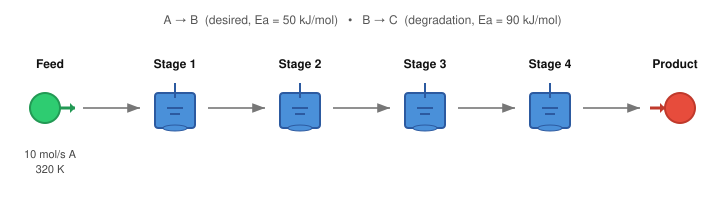

In [3]:
from IPython.display import SVG, display
from difflow.visualization import get_icon_svg

ICON, GAP, Y = 60, 125, 78


def _icon(name, x, y):
    """Place one of difflow's 60x60 unit icons at (x, y)."""
    s = get_icon_svg(name)
    return f'<g transform="translate({x},{y})">{s[s.index(">") + 1:s.rindex("</svg>")]}</g>'


def draw_process(V=None, T=None):
    """Process flow diagram of the reactor train, optionally annotated."""
    xs = [20 + GAP * i for i in range(N_STAGES + 2)]
    W, H = xs[-1] + ICON + 20, 210

    p = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{W}" height="{H}" viewBox="0 0 {W} {H}">',
         '<style>text{font-family:-apple-system,Segoe UI,Helvetica,sans-serif}'
         '.l{font-size:11px;fill:#444;text-anchor:middle}'
         '.v{font-size:11px;fill:#2c5aa0;text-anchor:middle}'
         '.h{font-size:12px;fill:#111;text-anchor:middle;font-weight:600}'
         '.r{font-size:12px;fill:#555;text-anchor:middle}</style>',
         '<defs><marker id="ar" markerWidth="9" markerHeight="9" refX="8" refY="3" orient="auto">'
         '<path d="M0,0 L8,3 L0,6 z" fill="#777"/></marker></defs>',
         f'<text class="r" x="{W/2}" y="24">A → B &#160;(desired, Ea = 50 kJ/mol)'
         '&#160;&#160;&#160;&#8226;&#160;&#160;&#160;B → C &#160;(degradation, Ea = 90 kJ/mol)</text>']

    for i in range(N_STAGES + 1):
        p.append(f'<line x1="{xs[i]+ICON+3}" y1="{Y+30}" x2="{xs[i+1]-5}" y2="{Y+30}" '
                 'stroke="#777" stroke-width="1.6" marker-end="url(#ar)"/>')

    for i, (nm, x) in enumerate(zip(["Feed"] + ["CSTR"] * N_STAGES + ["Product"], xs)):
        p.append(_icon(nm, x, Y))
        c = x + ICON / 2
        if 1 <= i <= N_STAGES:
            k = i - 1
            p.append(f'<text class="h" x="{c}" y="{Y-10}">Stage {k+1}</text>')
            if V is not None:
                p.append(f'<text class="v" x="{c}" y="{Y+ICON+20}">V = {V[k]:.3f} m³</text>')
                p.append(f'<text class="v" x="{c}" y="{Y+ICON+35}">T = {T[k]:.1f} K</text>')

    p.append(f'<text class="h" x="{xs[0]+ICON/2}" y="{Y-10}">Feed</text>')
    p.append(f'<text class="l" x="{xs[0]+ICON/2}" y="{Y+ICON+20}">{FEED:.0f} mol/s A</text>')
    p.append(f'<text class="l" x="{xs[0]+ICON/2}" y="{Y+ICON+35}">{FEED_T:.0f} K</text>')
    p.append(f'<text class="h" x="{xs[-1]+ICON/2}" y="{Y-10}">Product</text>')
    p.append('</svg>')
    return "\n".join(p)


SVG(draw_process())

## 2. Why an equation-oriented formulation

There are two ways to hand this model to an optimizer.

**Sequential-modular.** Call `reactor(inlet, T_spec=...)` and let difflow solve
the reactor internally. The decision variables are just $(V_k, T_k)$, and the
reactor's material balance is closed by an inner Newton solve. This works fine
with pounce, but the inner solve is opaque: it emits a `linear_solve` primitive
into the jaxpr (via optimistix/lineax), which asdex cannot trace through. There
is also nothing for asdex to find -- with only $2N$ variables the Jacobian is
effectively dense.

**Equation-oriented.** Promote the stream variables to decision variables and
add the model equations as equality constraints. The model is now a set of
*explicit residuals* -- no inner solver -- so asdex can trace it, and the
Jacobian is large and genuinely sparse because stage $k$ only touches stages
$k-1$ and $k$. This is how full-space process optimizers work, and it is the
formulation where sparsity detection earns its keep.

difflow exposes exactly what we need: `CSTR.eo_residuals` returns the residual
form of the unit.

Per stage the unknowns are $[V_k,\ T_k,\ F_{A,k},\ F_{B,k},\ F_{C,k}]$, so
$n = 5N = 20$. The constraints are $N$ blocks of 3 material balances plus the
conversion spec, so $m = 3N + 1 = 13$.

In [4]:
N_VARS = 5  # V, T, F_A, F_B, F_C per stage
n = N_STAGES * N_VARS
m = N_STAGES * N_SPECIES + 1


def stage(z, k):
    """Unpack stage k: returns (V, T, F) with F = [F_A, F_B, F_C]."""
    b = k * N_VARS
    return z[b], z[b + 1], z[b + 2:b + 5]


def residuals(z):
    """Material-balance residuals for the whole train, straight from difflow."""
    out = []
    prev = make_stream({"A": FEED, "B": 0.0, "C": 0.0}, T=FEED_T, P=P0)

    for k in range(N_STAGES):
        V, T, F = stage(z, k)
        outlet = make_stream({"A": F[0], "B": F[1], "C": F[2]}, T=T, P=P0)
        r = make_reactor(V).eo_residuals([prev], [outlet], volumetric_flow=QV)
        # eo_residuals returns n_species material balances plus a T row and a P
        # row. Here T is a decision variable and P is fixed, so those two rows
        # are identities (0 = 0) -- keep only the material balances.
        out.append(r[:N_SPECIES])
        prev = outlet

    return jnp.concatenate(out)


def conversion(z):
    """Overall conversion of A across the train."""
    return (FEED - stage(z, N_STAGES - 1)[2][0]) / FEED


def g(z):
    """Constraint vector: model residuals, then the conversion spec."""
    return jnp.concatenate([residuals(z), jnp.atleast_1d(conversion(z))])


print(f"n = {n} variables, m = {m} constraints")

n = 20 variables, m = 13 constraints


## 3. The objective

Profit per second: revenue from B, less feedstock and annualized reactor
capital. Capital scales as $V^{0.6}$, the usual economy-of-scale exponent.
Note that nothing penalizes temperature directly -- the only reason not to run
hot is that it destroys product.

In [5]:
PRICE_B = 2.0     # $/mol of B sold
PRICE_A = 0.60    # $/mol of A fed
CAPITAL = 1.5     # $/s per (m^3)^0.6, annualized


def profit(z):
    """Profit rate ($/s)."""
    F_B = stage(z, N_STAGES - 1)[2][1]
    capital = sum(CAPITAL * stage(z, k)[0] ** 0.6 for k in range(N_STAGES))
    return PRICE_B * F_B - PRICE_A * FEED - capital


def f(z):
    """pounce minimizes, so minimize the negative profit."""
    return -profit(z)


# Starting point: a rough guess, not feasible -- the solver closes the residuals.
z0 = jnp.array([0.5, 360.0, 5.0, 4.0, 0.5] * N_STAGES)

print(f"profit(z0)   = {float(profit(z0)):+.4f} $/s")
print(f"|residuals|  = {float(jnp.linalg.norm(residuals(z0))):.3f}  (infeasible start)")

profit(z0)   = -1.9585 $/s


|residuals|  = 36.424  (infeasible start)


## 4. Sparsity detection with asdex

`asdex.jacobian_sparsity` analyzes the *computation graph* rather than
evaluating derivatives, so the pattern it returns is valid for all inputs, and
it never has to evaluate the model at a point where it might not be defined.

That last part matters more than it sounds. pounce's own built-in fallback
discovers sparsity by probing derivatives at random $\mathcal{N}(0,1)$ points --
which for a process model means $T \approx -1.3$ K, where the Arrhenius terms
overflow and the model blows up. Symbolic detection sidesteps that entirely.

For the Lagrangian Hessian, pounce needs the union of the structures of
$\nabla^2 f$ and each $\nabla^2 g_i$. Taking $\lambda = 1$ gives exactly that
union.

In [6]:
jac_pattern = asdex.jacobian_sparsity(g, z0)


def lagrangian(z):
    """Structural stand-in for the Lagrangian: lambda = 1 gives the union."""
    return f(z) + jnp.sum(g(z))


hess_pattern = asdex.hessian_sparsity(lagrangian, z0)

print(f"Jacobian: {jac_pattern.m} x {jac_pattern.n}, "
      f"{jac_pattern.nnz} nonzeros ({jac_pattern.density:.1%} dense)")
print(f"Hessian:  {hess_pattern.m} x {hess_pattern.n}, "
      f"{hess_pattern.nnz} nonzeros ({hess_pattern.density:.1%} dense)")

Jacobian: 13 x 20, 62 nonzeros (23.8% dense)
Hessian:  20 x 20, 48 nonzeros (12.0% dense)


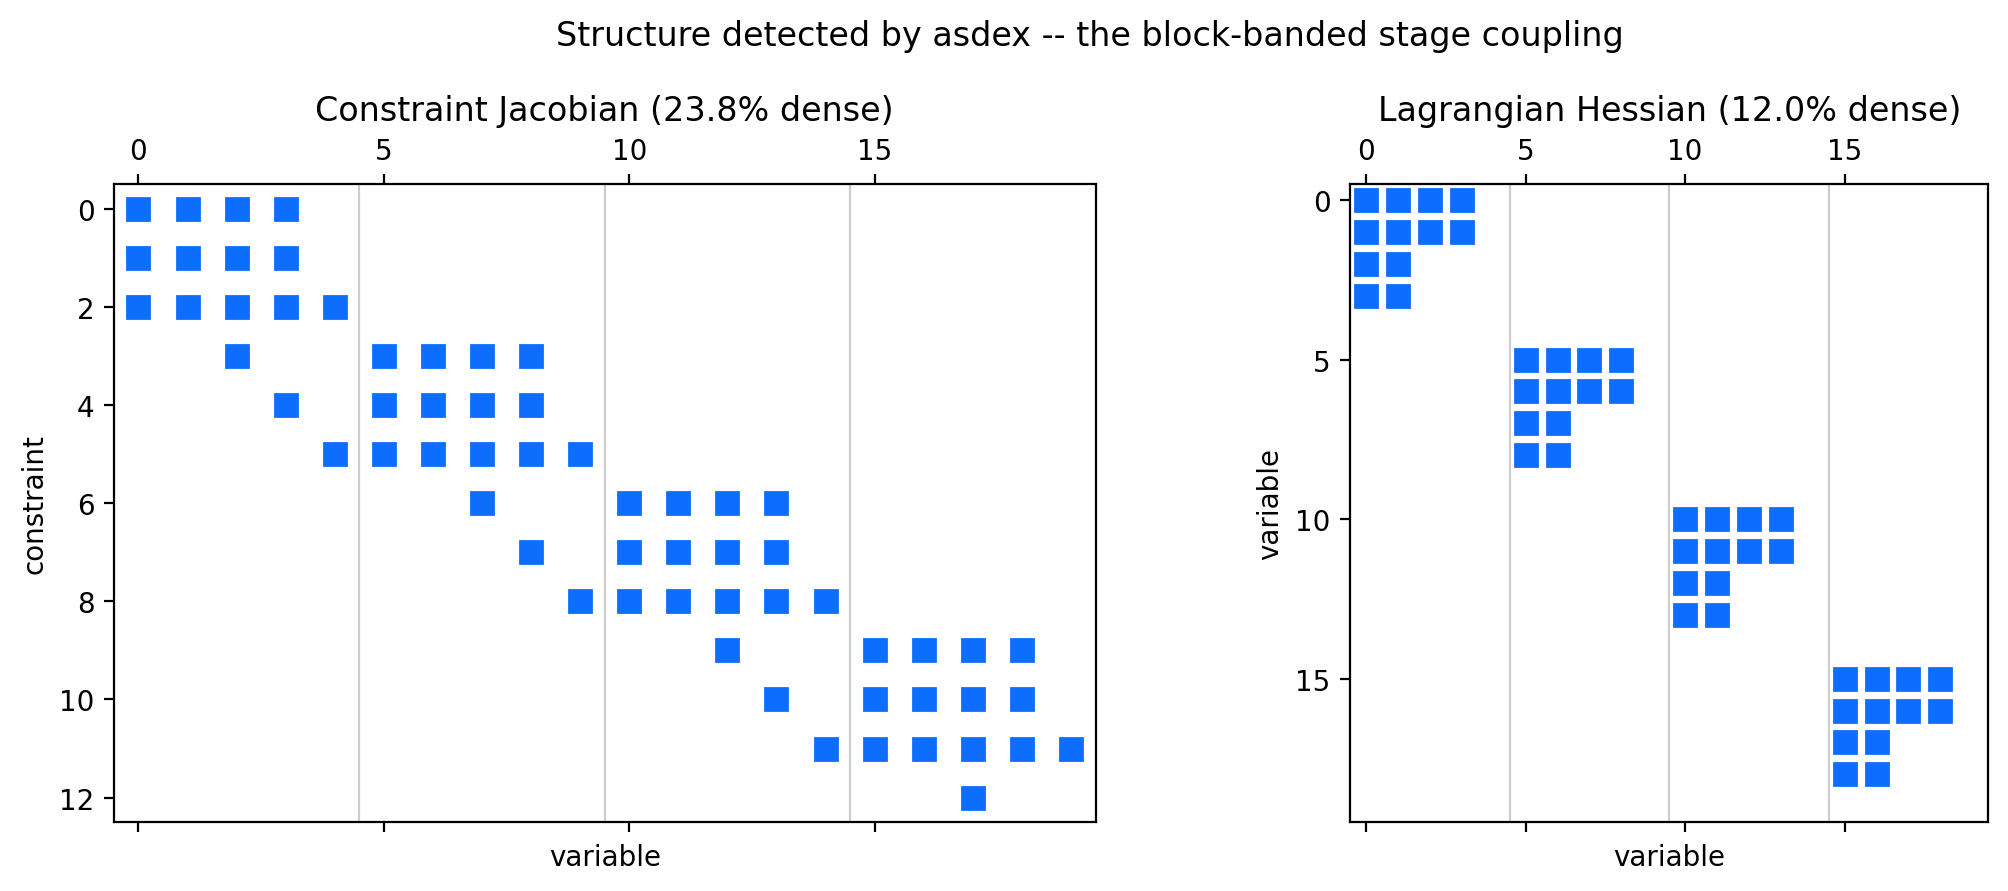

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].spy(np.asarray(jac_pattern.todense()), markersize=8)
axes[0].set_title(f"Constraint Jacobian ({jac_pattern.density:.1%} dense)")
axes[0].set_xlabel("variable")
axes[0].set_ylabel("constraint")

axes[1].spy(np.asarray(hess_pattern.todense()), markersize=8)
axes[1].set_title(f"Lagrangian Hessian ({hess_pattern.density:.1%} dense)")
axes[1].set_xlabel("variable")
axes[1].set_ylabel("variable")

for ax in axes:
    for b in range(1, N_STAGES):
        ax.axvline(b * N_VARS - 0.5, color="0.8", lw=0.8, zorder=0)

fig.suptitle("Structure detected by asdex -- the block-banded stage coupling")
fig.tight_layout()
plt.show()

The block structure is the flowsheet topology made visible: each stage's three
material balances touch only that stage's five variables plus the two inlet
flows it inherits from the stage upstream. The last Jacobian row is the
conversion spec, which touches a single variable ($F_A$ in the final stage).

A sparsity pattern is only safe if it is a **superset** of the true structure --
a missing entry silently drops a derivative. asdex claims its pattern holds for
all inputs; let's check that against a dense AD Jacobian.

In [8]:
J_pattern = np.asarray(jac_pattern.todense()) != 0
J_true = np.abs(np.asarray(jax.jacobian(g)(z0))) > 0

print(f"superset of the true structure: {bool((J_true <= J_pattern).all())}")
print(f"asdex {J_pattern.sum()} nonzeros | actually nonzero at z0 {J_true.sum()} "
      f"| dense would be {n * m}")

superset of the true structure: True
asdex 62 nonzeros | actually nonzero at z0 54 | dense would be 260


A valid superset, and a third of the dense cost. The eight extra entries are
structurally-possible couplings that happen to evaluate to zero at this
particular point -- exactly the conservative side to err on.

## 5. Solve with pounce

`from_jax` builds a `pounce.Problem`, deriving the gradient, Jacobian and
Lagrangian Hessian from `f` and `g` with `jax.grad`/`jacrev`/`hessian`.
Passing the patterns skips pounce's own probe entirely, and `sparse=True`
switches the per-iteration derivatives to CPR-style colored AD -- one
JVP/HVP per color instead of building the dense matrix and slicing it.

The equality constraints are the model residuals, so `cl = cu = 0` for those
rows. The conversion spec gets `[0.97, 1.0]`.

In [9]:
rows, cols = np.nonzero(J_pattern)
hrows, hcols = np.nonzero(np.asarray(hess_pattern.todense()) != 0)

# Bounds, per stage: V (m^3), T (K), then the three species flows (mol/s).
lb = jnp.array([0.01, 320.0, 0.0, 0.0, 0.0] * N_STAGES)
ub = jnp.array([5.00, 420.0, FEED, FEED, FEED] * N_STAGES)

# Residual rows are equalities; the last row is the conversion spec.
cl = jnp.concatenate([jnp.zeros(N_STAGES * N_SPECIES), jnp.array([0.97])])
cu = jnp.concatenate([jnp.zeros(N_STAGES * N_SPECIES), jnp.array([1.00])])

problem = from_jax(
    f, g, n=n, m=m, lb=lb, ub=ub, cl=cl, cu=cu,
    sparse=True,                       # colored AD using the patterns below
    jac_pattern=(rows, cols),          # from asdex -- no probing
    hess_pattern=(hrows, hcols),       # pounce folds this onto the lower triangle
)
problem.add_option("print_level", 0)
problem.add_option("tol", 1e-8)

z, info = problem.solve(x0=z0)
print(f"pounce: {info['status_msg']}")

pounce: Solve_Succeeded


In [10]:
print(f"profit       = {float(profit(z)):+.4f} $/s "
      f"(started at {float(profit(z0)):+.4f})")
print(f"conversion   = {float(conversion(z)):.4f}   (spec: >= 0.97)")
print(f"|residuals|  = {float(jnp.linalg.norm(residuals(z))):.2e}   (model is satisfied)")
print()
print(f"{'stage':>6} {'V (m^3)':>9} {'tau (s)':>9} {'T (K)':>8} "
      f"{'F_A':>7} {'F_B':>7} {'F_C':>7}")
for k in range(N_STAGES):
    V, T, F = stage(z, k)
    print(f"{k + 1:>6} {float(V):>9.4f} {float(V) / QV:>9.1f} {float(T):>8.1f} "
          f"{float(F[0]):>7.3f} {float(F[1]):>7.3f} {float(F[2]):>7.3f}")

F_B_final = float(stage(z, N_STAGES - 1)[2][1])
print(f"\nselectivity  = {F_B_final / (FEED * float(conversion(z))):.4f} "
      f"mol B per mol A converted")

profit       = +10.4739 $/s (started at -1.9585)
conversion   = 0.9700   (spec: >= 0.97)
|residuals|  = 2.07e-09   (model is satisfied)

 stage   V (m^3)   tau (s)    T (K)     F_A     F_B     F_C
     1    0.0703       7.0    386.0   4.536   5.340   0.124
     2    0.1159      11.6    377.8   1.876   7.836   0.288
     3    0.1357      13.6    375.3   0.754   8.781   0.465
     4    0.1439      14.4    374.3   0.300   9.056   0.644

selectivity  = 0.9336 mol B per mol A converted


The same process diagram, now annotated with the optimal design:

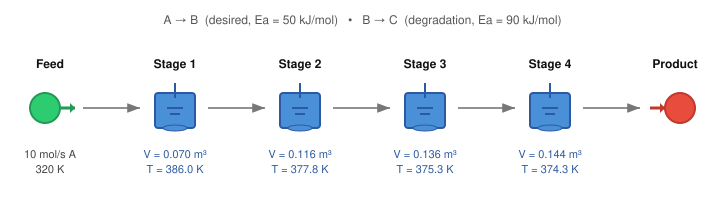

In [11]:
V = [float(stage(z, k)[0]) for k in range(N_STAGES)]
T = [float(stage(z, k)[1]) for k in range(N_STAGES)]

SVG(draw_process(V, T))

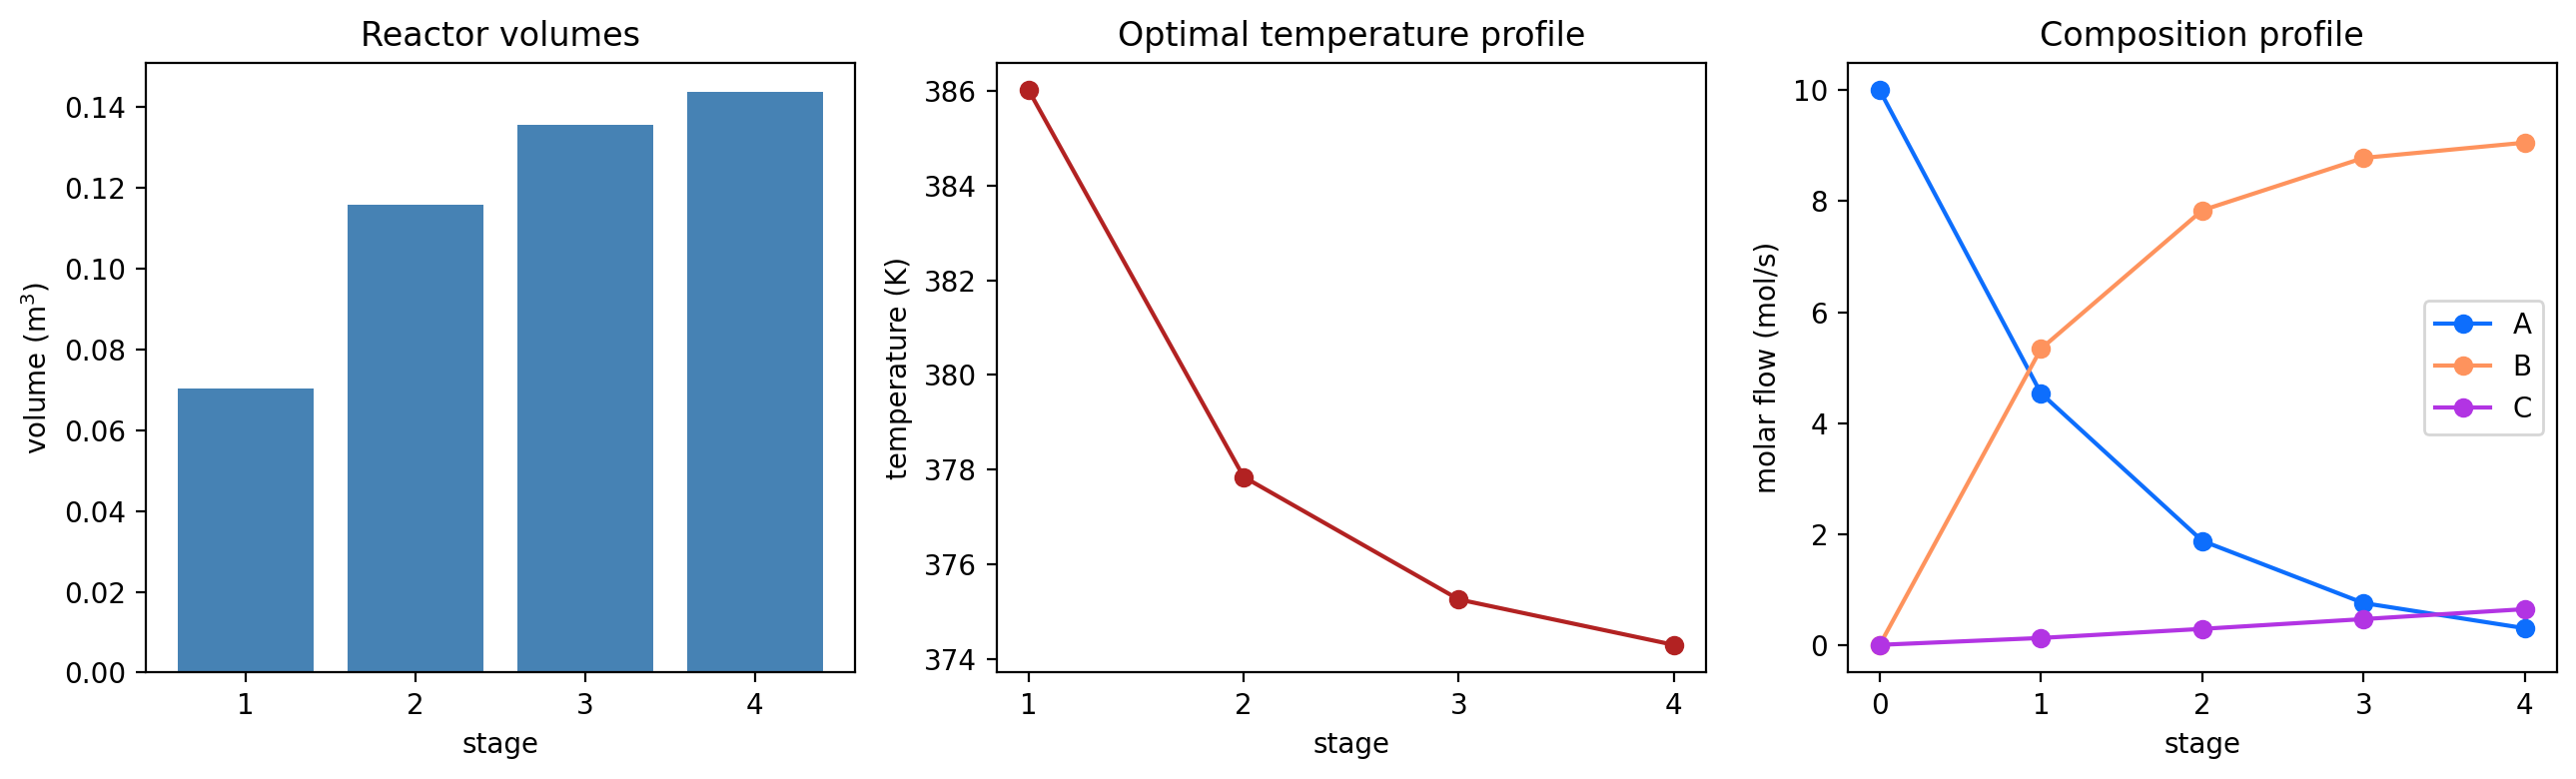

In [12]:
F = np.array([[float(v) for v in stage(z, k)[2]] for k in range(N_STAGES)])
stages = np.arange(1, N_STAGES + 1)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].bar(stages, V, color="steelblue")
axes[0].set(xlabel="stage", ylabel="volume (m$^3$)", title="Reactor volumes",
            xticks=stages)

axes[1].plot(stages, T, "o-", color="firebrick")
axes[1].set(xlabel="stage", ylabel="temperature (K)",
            title="Optimal temperature profile", xticks=stages)

for i, s in enumerate(SPECIES):
    axes[2].plot(np.r_[0, stages], np.r_[FEED if s == "A" else 0.0, F[:, i]],
                 "o-", label=s)
axes[2].set(xlabel="stage", ylabel="molar flow (mol/s)", title="Composition profile",
            xticks=np.r_[0, stages])
axes[2].legend()

fig.tight_layout()
plt.show()

## What the optimizer found

The temperature profile is **decreasing** down the train, and that is the whole
story of this problem. Early on the stream is mostly A and there is little B to
lose, so it pays to run hot and drive the desired reaction. As B accumulates, the
degradation reaction -- with its higher activation energy -- becomes the dominant
risk, so the optimal policy cools the later stages to protect the product. The
volumes grow down the train to compensate for the slower kinetics.

Nobody encoded that policy. It falls out of maximizing profit subject to the
model equations, with every derivative supplied by AD through the difflow model.

## Summary of the three-library split

| Library | Role | Entry point |
|---------|------|-------------|
| difflow | the process model, as explicit residuals | `CSTR.eo_residuals` |
| asdex | sparsity structure, from the computation graph | `jacobian_sparsity`, `hessian_sparsity` |
| pounce | the NLP solve | `pounce.jax.from_jax`, `Problem.solve` |

Two practical notes if you adapt this:

- **asdex needs a solver-free model.** It cannot trace the `linear_solve`
  primitive that optimistix and lineax emit, so a sequential-modular call like
  `reactor(inlet, T_spec=...)` -- which closes the material balance with an
  inner Newton solve -- will not trace. The equation-oriented residual form has
  no inner solve, which is what makes this work. (This also means most difflow
  units need `eo_residuals` for this approach.)
- **A supplied pattern is a promise pounce does not check.** It must be a
  superset of the true structure; extra entries cost a little, missing entries
  are silently wrong. The verification cell above is worth keeping.

### Requirements

```
pip install pounce-solver[jax] asdex
```

`asdex >= 0.5.2` requires `jax >= 0.11`; on `jax 0.10` install `asdex == 0.5.1`.